# 10 — The Most Improved leap, week by week

**Questions**
1. Did past Most Improved Player (MIP) winners improve **steadily through the season**, or jump at a specific point (a hot start, after the All-Star break, after a role change)?
2. Is a single huge night (Malachi Flynn's 50 points) an **indicator or a fluke**?
3. How much does a **3-, 5- or 7-game rolling average** tell you about the rest of the season?
4. (Next) Can we pick the MIP in retrospect, and was Nickeil Alexander-Walker's 2025-26 leap a **blip**?

**Decisions**
- **Production** = Hollinger **game score** (headline: one number for a game's box-score impact), shown alongside points, minutes, shot volume (shots + turnovers), assists and rebounds.
- **Baseline** = the player's per-game averages in his **most recent previous season played**.
- **Form** = 3-, 5- and 7-game rolling averages; weekly averages for display.
- MIP prediction will be limited to players with **≥ 2 previous seasons** (predicting from year 3 on).

Data: NBA.com league-wide game logs, 2010-11 → 2025-26 (404k player-games; 2010-11 only supplies 2011-12 baselines).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.gamelogs import build_game_table
from unicorn.labels import MIP_WINNERS
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
games, base, asb = build_game_table()
games.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_games.parquet", index=False)
print(games.shape)
asb

(404431, 60)


,season,last_game_before,first_game_after,gap_days
0,2010-11,2011-02-17,2011-02-22,5
1,2011-12,2012-02-23,2012-02-28,5
2,2012-13,2013-02-14,2013-02-19,5
3,2013-14,2014-02-13,2014-02-18,5
4,2014-15,2015-02-12,2015-02-19,7
5,2015-16,2016-02-11,2016-02-18,7
6,2016-17,2017-02-16,2017-02-23,7
7,2017-18,2018-02-15,2018-02-22,7
8,2018-19,2019-02-14,2019-02-21,7
9,2019-20,2020-02-13,2020-02-20,7


## 10B — How did each Most Improved winner's season unfold?

In [2]:
mip = pd.DataFrame([{"season": s, "player_id": pid} for s, pid in MIP_WINNERS.items()])
w = games.merge(mip, on=["season", "player_id"])
asb_week = games[games["after_all_star"]].groupby("season")["week"].min()

rows = []
for (s, pid), d in w.groupby(["season", "player_id"]):
    rows.append({"season": s, "player": d["player_name"].iloc[0],
                 "baseline": d["base_game_score"].iloc[0],
                 "first_10_games": d.head(10)["game_score"].mean(),
                 "before_all_star": d.loc[~d["after_all_star"], "game_score"].mean(),
                 "after_all_star": d.loc[d["after_all_star"], "game_score"].mean(),
                 "season_avg": d["game_score"].mean(),
                 "min_baseline": d["base_min"].iloc[0], "min_first_10": d.head(10)["min"].mean(), "min_season": d["min"].mean()})
summary = pd.DataFrame(rows)
summary["leap"] = summary["season_avg"] - summary["baseline"]
summary["share_of_leap_in_first_10"] = (summary["first_10_games"] - summary["baseline"]) / summary["leap"]
summary["post_vs_pre_all_star"] = summary["after_all_star"] - summary["before_all_star"]
summary.round(2)

,season,player,baseline,first_10_games,before_all_star,after_all_star,season_avg,min_baseline,min_first_10,min_season,leap,share_of_leap_in_first_10,post_vs_pre_all_star
0,2011-12,Ryan Anderson,8.48,14.20,13.25,12.80,13.05,22.17,30.6,32.16,4.57,1.25,-0.45
1,2012-13,Paul George,9.60,9.08,13.28,12.57,13.03,29.59,36.8,37.59,3.43,-0.15,-0.70
2,2013-14,Goran Dragic,12.54,11.88,16.27,14.81,15.73,33.53,32.3,35.13,3.19,-0.21,-1.46
3,2014-15,Jimmy Butler III,10.98,18.46,17.40,16.16,17.09,38.70,39.9,38.69,6.11,1.22,-1.24
4,2015-16,CJ McCollum,4.34,12.75,13.29,13.98,13.53,15.69,34.7,34.70,9.19,0.91,0.69
5,2016-17,Giannis Antetokounmpo,14.16,19.01,20.85,19.45,20.40,35.31,34.1,35.59,6.23,0.78,-1.41
6,2017-18,Victor Oladipo,10.48,16.59,18.27,15.73,17.49,33.21,32.5,34.08,7.01,0.87,-2.55
7,2018-19,Pascal Siakam,6.65,10.52,13.58,15.15,14.01,20.65,26.9,31.86,7.36,0.53,1.57
8,2019-20,Brandon Ingram,11.77,18.64,17.93,12.72,16.67,33.87,32.4,33.95,4.89,1.40,-5.21
9,2020-21,Julius Randle,13.74,18.36,18.29,18.07,18.18,32.53,37.8,37.55,4.45,1.04,-0.22


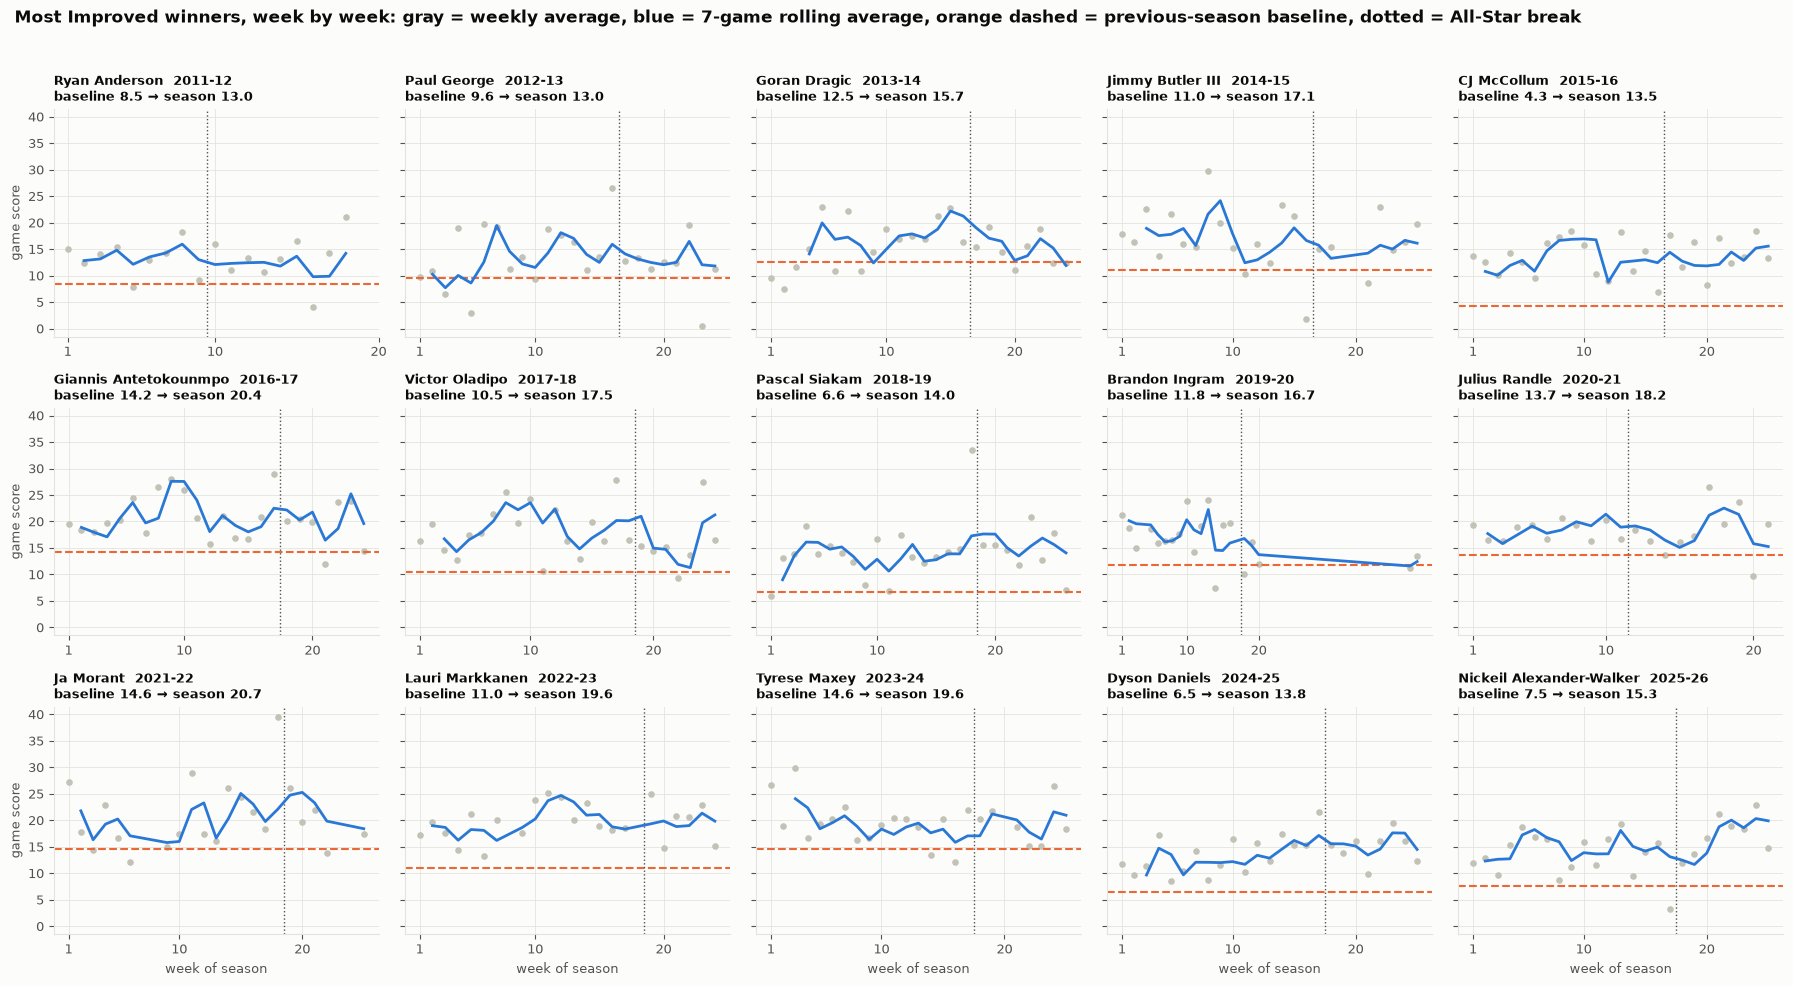

In [3]:
winners = summary.sort_values("season")
fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharey=True)
for ax, (_, r) in zip(axes.flat, winners.iterrows()):
    d = w[(w["season"] == r["season"]) & (w["player_name"] == r["player"])]
    weekly = d.groupby("week")["game_score"].mean()
    roll = d.groupby("week")["game_score_roll7"].last()
    ax.scatter(weekly.index, weekly.values, s=14, color=MUTED, zorder=2)
    ax.plot(roll.index, roll.values, color=BLUE, linewidth=2, zorder=3)
    ax.axhline(r["baseline"], color=ORANGE, linestyle="--", linewidth=1.5)
    ax.axvline(asb_week[r["season"]] - 0.5, color=INK2, linestyle=":", linewidth=1)
    ax.set_title(f"{r['player']}  {r['season']}\nbaseline {r['baseline']:.1f} → season {r['season_avg']:.1f}", loc="left", fontsize=9.5)
    ax.set_xticks([1, 10, 20])
for ax in axes[:, 0]:
    ax.set_ylabel("game score")
for ax in axes[-1]:
    ax.set_xlabel("week of season")
fig.suptitle("Most Improved winners, week by week: gray = weekly average, blue = 7-game rolling average, "
             "orange dashed = previous-season baseline, dotted = All-Star break", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96)); fig.savefig(FIG_DIR / "10_mip_week_by_week.png", dpi=150, bbox_inches="tight")

## 10C — One huge night: indicator or fluke?

An **eruption** is a game with a game score at least **20 above the player's baseline** (Flynn's 50: 42.0 vs a baseline of 3.0). Compare how the player did in the **7 games before** and the **7 games after** against his baseline.

In [4]:
g = games[games["base_game_score"].notna()].copy()
g["excess"] = g["game_score"] - g["base_game_score"]
ps = g.groupby(["player_id", "season_start"])["excess"]
g["prev7"] = ps.transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
g["next7"] = ps.transform(lambda s: s[::-1].shift(1).rolling(7, min_periods=7).mean()[::-1])
eruptions = g[g["excess"] >= 20].dropna(subset=["prev7", "next7"])
others = g.dropna(subset=["prev7", "next7"])
print(f"{len(eruptions)} eruption games (with 7 games either side) out of {len(others):,} games")
print(f"after an eruption, next 7 games vs baseline: {eruptions['next7'].mean():+.1f} game score "
      f"(the 7 before: {eruptions['prev7'].mean():+.1f}); for all games: next 7 {others['next7'].mean():+.1f}")
flynn = g[(g["player_name"] == "Malachi Flynn") & (g["pts"] >= 50)]
display(flynn[["season", "game_date", "matchup", "min", "pts", "game_score", "base_game_score", "prev7", "next7"]].round({"game_score": 1, "base_game_score": 1, "prev7": 1}))
print("Flynn's remaining games that season:")
f_season = g[(g["player_name"] == "Malachi Flynn") & (g["season"] == flynn["season"].iloc[0])]
display(f_season[f_season["game_date"] >= flynn["game_date"].iloc[0]][["game_date", "matchup", "min", "pts", "game_score"]])

1184 eruption games (with 7 games either side) out of 246,818 games
after an eruption, next 7 games vs baseline: +3.8 game score (the 7 before: +3.5); for all games: next 7 +0.4


,season,game_date,matchup,min,pts,game_score,base_game_score,prev7,next7
356021,2023-24,2024-04-03,DET @ ATL,34.0,50,42.0,3.0,4.7,NaN


Flynn's remaining games that season:


,game_date,matchup,min,pts,game_score
356021,2024-04-03,DET @ ATL,34.0,50,42.0
356022,2024-04-05,DET @ MEM,23.0,3,-1.3
356023,2024-04-06,DET @ BKN,15.0,3,-0.1
356024,2024-04-09,DET @ PHI,21.0,12,7.7
356025,2024-04-11,DET vs. CHI,15.0,12,5.9
356026,2024-04-12,DET @ DAL,16.0,10,12.1
356027,2024-04-14,DET @ SAS,20.0,4,1.6


In [5]:
# Was the eruption a sign of a real step up? Bucket by what the 7 games BEFORE looked like
eruptions = eruptions.assign(form_before=pd.cut(eruptions["prev7"], [-99, 0, 3, 99], labels=["below baseline", "slightly above (0–3)", "already well above (3+)"]))
t = eruptions.groupby("form_before", observed=True).agg(eruptions=("next7", "size"), next7_vs_baseline=("next7", "mean"),
                                                         prev7_vs_baseline=("prev7", "mean"))
t.round(2)

,eruptions,next7_vs_baseline,prev7_vs_baseline
form_before,,,
below baseline,243,1.00,-2.00
slightly above (0–3),336,2.73,1.63
already well above (3+),605,5.54,6.69


## 10D — How much do 3, 5 and 7-game averages tell you?

At a given point in the season (after game *n*), take the player's last-*k*-games average (relative to his baseline) and see how well it predicts his **rest-of-season** average (also relative to baseline). Correlation across all player-seasons with at least *n* + 15 games, ≥ 15 min per game in the baseline season.

window,last game,last 3,last 5,last 7,season to date
after game,,,,,
7,0.32,0.45,0.53,0.57,0.57
15,0.31,0.45,0.52,0.56,0.64
25,0.31,0.47,0.53,0.58,0.68
40,0.33,0.48,0.54,0.58,0.69


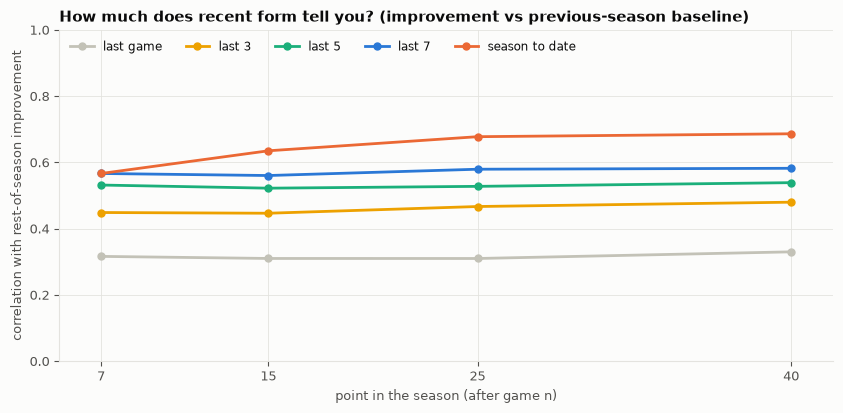

In [6]:
rows = []
gg = g[g["base_min"] >= 15].copy()
gg["games_in_season"] = gg.groupby(["player_id", "season_start"])["game_number"].transform("max")
for n in [7, 15, 25, 40]:
    cut = gg[gg["games_in_season"] >= n + 15]
    at_n = cut[cut["game_number"] == n].set_index(["player_id", "season_start"])
    rest = cut[cut["game_number"] > n].groupby(["player_id", "season_start"])["excess"].mean()
    to_date = cut[cut["game_number"] <= n].groupby(["player_id", "season_start"])["excess"].mean()
    preds = {"last game": at_n["excess"], **{f"last {k}": at_n[f"game_score_roll{k}"] - at_n["base_game_score"] for k in (3, 5, 7)},
             "season to date": to_date}
    for name, p in preds.items():
        rows.append({"after game": n, "window": name, "corr_with_rest_of_season": p.corr(rest.reindex(p.index)), "player_seasons": len(p)})
corr = pd.DataFrame(rows).pivot(index="after game", columns="window", values="corr_with_rest_of_season")
corr = corr[["last game", "last 3", "last 5", "last 7", "season to date"]]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for name, color in zip(corr.columns, [MUTED, SERIES[3], SERIES[2], SERIES[0], SERIES[1]]):
    ax.plot(corr.index, corr[name], color=color, marker="o", markersize=5, label=name)
ax.set_xticks(corr.index); ax.set_xlim(5, 42); ax.set_ylim(0, 1)
ax.set_xlabel("point in the season (after game n)"); ax.set_ylabel("correlation with rest-of-season improvement")
ax.legend(frameon=False, loc="upper left", ncol=5, fontsize=8.5)
ax.set_title("How much does recent form tell you? (improvement vs previous-season baseline)", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_rolling_window_signal.png", dpi=150, bbox_inches="tight")
corr.round(2)

## Findings so far

**How winners' seasons unfolded (10B):**
- **Most MIP leaps were there from day one.** For 11 of 15 winners, the first 10 games already showed 80%+ of the full-season jump in game score. The leap usually came with a **new role from opening night**: McCollum 15.7 → 34.7 minutes, Daniels 22.3 → 33.0, Anderson 22.2 → 30.6.
- **Three grew into it during the season:** Paul George and Dragić started at their baseline and climbed; Siakam showed half the leap early, then kept rising.
- **The All-Star break rarely mattered.** Most winners were flat or slightly *down* after it (Ingram −5.2, mostly the 2020 bubble). The exceptions rose: **Nickeil Alexander-Walker +3.7** (14.2 → 17.9), Daniels +1.9, Siakam +1.6.
- **NAW is the strongest late riser of all 15 winners.** He had only half his leap in the first 10 games, his minutes kept growing (30 → 33), and his best form came after the All-Star break (7-game average about 20 by season's end). Whether that late surge carries into 2026-27 is the "blip or real" question.

**One huge night: indicator or fluke? (10C)**
- Across 1,184 "eruption" games (game score ≥ 20 above baseline), the next 7 games averaged **+3.8 above baseline**, almost identical to the 7 games *before* (+3.5). **The eruption itself adds little; it mostly confirms form that was already there.**
- If the player was *below* his baseline before the eruption, the next 7 games averaged only +1.0. **Flynn is that case:** +4.7 in the 7 games before his 50-pointer, then game scores of −1.3, −0.1, 7.7, 5.9, 12.1 and 1.6 to finish the season. **A fluke.**

**Which window to trust (10D):**
- **A single game is a weak signal** (correlation about 0.3 with rest-of-season improvement); 3 games about 0.45, 5 about 0.53, 7 about 0.57.
- **Season-to-date wins once there are 15+ games** (0.64 → 0.69). The 7-game average is the best *short-term* gauge, but it never beats the full sample.

**Next:** (1) **blip or real**: what share of the leap winners and other big leapers keep the next season, and what predicts keeping it (age, early vs late leap, minutes change, shooting luck); (2) **pick the MIP in retrospect** for players with ≥ 2 previous seasons, including "who led at the All-Star break?".